# Neural Networks for Data Science — Final Homework
## Mini Causal Language Model with Key-Value Cache (Exercise 1) & KV compression (Exercise 2)

### 1936419 -- Saif Ali

----

### Disclaimer on the Use of AI Tools

For transparency and academic integrity, please note that Artificial Intelligence (AI) tools (specifically Large Language Models) were utilized as an educational and developmental aid in the creation of this notebook.

Specifically, AI assistance was used for the following purposes:
* **Ideation & Dataset Selection:** Brainstorming project directions and identifying appropriate datasets.
* **Strategic Guidance:** High-level advice on project structuring and implementation steps.
* **Theoretical Clarifications:** Deepening my understanding of complex machine learning concepts (e.g., Transformer architecture, KV caching, and compression).
* **Programming Assistance:** Resolving specific programming queries and debugging, particularly navigating the functional, immutable paradigms of **JAX** and **Equinox** and the **KV Compression**.

Additionally, certain code segments within this notebook represent optimized versions of my original draft attempts provided to the LLM for quick fixes.

*All final code, architectural choices, and theoretical explanations are carefully reviewed, understood, and integrated.*

----

This notebook implements a decoder-only Transformer trained on WikiText-2, and then extends the attention layer with a Key-Value (KV) cache for efficient autoregressive inference. Then, a KV cache compressed version of the same mini LLM

## 0. Environment Setup

The implementation relies on:
- `jax` for accelerated array computation and JIT compilation,
- `equinox` for neural network modules defined as PyTrees,
- `optax` for optimisation,
- `datasets` for loading WikiText-2,
- `transformers` for the GPT-2 tokenizer.

All random behaviour is controlled explicitly through PRNG keys, which is the idiomatic JAX design pattern.

In [1]:
%pip install -q datasets transformers equinox optax tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.3 MB/s eta 0:00:00


In [2]:
import math
import functools
from typing import Optional

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import GPT2TokenizerFast
from tqdm.auto import tqdm

print("JAX backend :", jax.default_backend())
print("JAX devices :", jax.devices())
print("JAX version :", jax.__version__)
print("Equinox ver :", eqx.__version__)

JAX backend : gpu
JAX devices : [CudaDevice(id=0)]
JAX version : 0.7.2
Equinox ver : 0.13.8


## 1. Dataset and Tokenisation

### WikiText-2

WikiText-2 is a standard language modelling dataset. It consists of selected Wikipedia articles and is of good enough size to train a compact Transformer on a Colab GPU.

### GPT-2 BPE Tokenizer

I am using the GPT-2 Byte-Pair Encoding (BPE) tokenizer with vocabulary size $V = 50,257$. BPE provides a good compromise between character-level and word-level tokenisation.

### Packed Training Windows

All non-empty articles are concatenated into a single token stream, with an EOS token inserted between articles. The stream is then partitioned into non-overlapping windows of length $T+1$, where $T$ is the context length. Each window yields:
- an input sequence $x_{1:T}$,
- a target sequence $x_{2:T+1}$.

This offset-by-one construction is the standard setup for causal next-token prediction.

In [3]:
#  Global constants
CONTEXT_LEN = 256
BATCH_SIZE  = 32
SEED        = 0

tokenizer  = GPT2TokenizerFast.from_pretrained("gpt2")
VOCAB_SIZE = tokenizer.vocab_size
EOS_ID     = tokenizer.eos_token_id

print(f"Vocabulary size : {VOCAB_SIZE:,}")
print(f"EOS token id   : {EOS_ID}")
print(f"Context length : {CONTEXT_LEN}")
print(f"Batch size     : {BATCH_SIZE}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Vocabulary size : 50,257
EOS token id   : 50256
Context length : 256
Batch size     : 32


In [4]:
raw_datasets = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

print(raw_datasets)
for split_name, split_data in raw_datasets.items():
    non_empty = [t for t in split_data["text"] if t.strip()]
    print(f"  {split_name:12s}  {len(split_data):6d} rows  ({len(non_empty):5d} non-empty)")

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
  test            4358 rows  ( 2891 non-empty)
  train          36718 rows  (23767 non-empty)
  validation      3760 rows  ( 2461 non-empty)


In [5]:
def tokenise_and_chunk(hf_split, tokenizer, context_len):
    """
    Convert a dataset split to a packed array of token windows.

    Steps
    -----
    1. Concatenate all non-empty texts.
    2. Insert EOS between documents.
    3. Trim to a multiple of (context_len + 1).
    4. Reshape to (n_windows, context_len + 1).
    """
    eos = tokenizer.eos_token_id
    all_ids = []

    for text in hf_split["text"]:
        if not text.strip():
            continue
        all_ids.extend(tokenizer.encode(text))
        all_ids.append(eos)

    token_array = np.array(all_ids, dtype=np.int32)
    print(f"  Raw token count : {len(token_array):,}")

    window = context_len + 1
    n_windows = len(token_array) // window
    token_array = token_array[: n_windows * window]
    chunks = token_array.reshape(n_windows, window)

    print(f"  Windows created : {n_windows:,}  (each length {window})")
    return chunks


print("Tokenising splits...\n")
train_chunks = tokenise_and_chunk(raw_datasets["train"], tokenizer, CONTEXT_LEN)
valid_chunks = tokenise_and_chunk(raw_datasets["validation"], tokenizer, CONTEXT_LEN)
test_chunks  = tokenise_and_chunk(raw_datasets["test"], tokenizer, CONTEXT_LEN)

print(f"\nShapes:")
print(f"  train : {train_chunks.shape}")
print(f"  valid : {valid_chunks.shape}")
print(f"  test  : {test_chunks.shape}")

Tokenising splits...

  Raw token count : 2,415,651
  Windows created : 9,399  (each length 257)
  Raw token count : 249,750
  Windows created : 971  (each length 257)
  Raw token count : 286,178
  Windows created : 1,113  (each length 257)

Shapes:
  train : (9399, 257)
  valid : (971, 257)
  test  : (1113, 257)


In [6]:
# Offset sanity check
_w = train_chunks[42]
_inp, _tgt = _w[:-1], _w[1:]

assert np.all(_inp[1:] == _tgt[:-1]), "Offset check failed."
print("Offset check passed.")
print(f"First 8 input tokens : {_inp[:8]}")
print(f"First 8 target tokens: {_tgt[:8]}")
print(f"Decoded preview      : {tokenizer.decode(_inp[:20])!r}")

Offset check passed.
First 8 input tokens : [15674   837  9722  8541   812   764  4930 14825]
First 8 target tokens: [  837  9722  8541   812   764  4930 14825  2594]
Decoded preview      : ' 1973 , aged 77 years . Two funeral services were held – one in Storrington Church and one'


### Mini-batch Loader

The training data is already packed into fixed windows, so batching is simply grouping rows of shape \((T+1)\). For each mini-batch:
- `inputs = batch[:, :-1]`
- `targets = batch[:, 1:]`

No extra padding is required, and no preprocessing is needed during training.

In [7]:
def make_batches(chunks, batch_size, shuffle=False, rng=None):
    """
    Yield (inputs, targets) mini-batches from a packed token array.

    Parameters
    ----------
    chunks     : np.ndarray of shape (n_windows, T+1)
    batch_size : int
    shuffle    : bool
    rng        : np.random.Generator, required when shuffle=True
    """
    n = len(chunks)
    indices = np.arange(n)

    if shuffle:
        if rng is None:
            raise ValueError("rng must be provided when shuffle=True")
        rng.shuffle(indices)

    for start in range(0, n - batch_size + 1, batch_size):
        batch_idx = indices[start : start + batch_size]
        batch = chunks[batch_idx]
        yield batch[:, :-1], batch[:, 1:]


_rng = np.random.default_rng(SEED)
_x, _y = next(make_batches(train_chunks, BATCH_SIZE, shuffle=True, rng=_rng))

print(f"inputs  shape : {_x.shape}, dtype : {_x.dtype}")
print(f"targets shape : {_y.shape}, dtype : {_y.dtype}")
assert np.all(_x[:, 1:] == _y[:, :-1]), "Loader consistency check failed."
print("Loader consistency check passed.")

inputs  shape : (32, 256), dtype : int32
targets shape : (32, 256), dtype : int32
Loader consistency check passed.


## 2. Baseline Transformer Architecture

I am implement a compact decoder-only Transformer in the GPT-style autoregressive setting.

### Hyperparameters

The model is deliberately small enough to train on a Colab T4 while still preserving the standard Transformer design:
- $L = 4$ decoder blocks,
- $d_{\text{model}} = 256$,
- $H = 4$ heads,
- $d_h = d_{\text{model}} / H = 64$,
- $d_{ff} = 4d_{\text{model}} = 1024$,
- dropout $= 0.1$.

### Design Choices

- **Pre-LN residual blocks** are used for training stability.
- **GELU** is used in the feed-forward network, matching GPT-2.
- **Weight tying** is used between the token embedding matrix and the output projection, reducing parameters.
- Token embeddings are manually initialised to N$(0, 0.02)$ to match GPT-2-style scaling.

In [8]:
N_LAYERS = 4
D_MODEL  = 256
N_HEADS  = 4
D_FF     = 4 * D_MODEL
DROPOUT  = 0.1

assert D_MODEL % N_HEADS == 0, "d_model must be divisible by n_heads."
D_HEAD = D_MODEL // N_HEADS

print(f"Model config: L={N_LAYERS}, d={D_MODEL}, H={N_HEADS}, d_h={D_HEAD}, d_ff={D_FF}")

Model config: L=4, d=256, H=4, d_h=64, d_ff=1024


### Causal Attention Mask

For autoregressive language modelling, token $i$ must not attend to any future token $j > i$. This is enforced with a lower-triangular boolean mask:
$$
M_{ij} =
\begin{cases}
1 & \text{if } j \le i \\
0 & \text{otherwise}
\end{cases}
$$

Before applying softmax, masked positions receive a large negative score (here $-10^9$), which forces their attention weight to zero.

In [9]:
def causal_mask(seq_len: int) -> jnp.ndarray:
    """Return a lower-triangular boolean mask of shape (seq_len, seq_len)."""
    return jnp.tril(jnp.ones((seq_len, seq_len), dtype=bool))

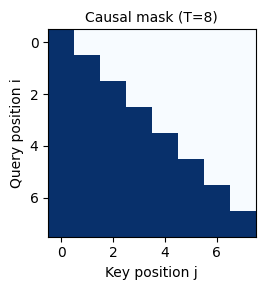

In [10]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(causal_mask(8), cmap="Blues", vmin=0, vmax=1)
ax.set_title("Causal mask (T=8)", fontsize=10)
ax.set_xlabel("Key position j")
ax.set_ylabel("Query position i")
plt.tight_layout()
plt.show()

### Multi-Head Self-Attention

Given an input sequence $X \in \mathbb{R}^{T \times d}$, the model computes:
$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

Each is reshaped into $H$ heads of dimension $d_h$, and scaled dot-product attention is applied independently per head:
$$
\text{Attention}(Q_h, K_h, V_h) =
\text{softmax}\left(\frac{Q_h K_h^\top}{\sqrt{d_h}}\right)V_h
$$

The outputs of all heads are concatenated and projected back to $d_{\text{model}}$. In training, dropout is applied to the attention weights.

In [11]:
class MultiHeadSelfAttention(eqx.Module):
    W_q:          eqx.nn.Linear
    W_k:          eqx.nn.Linear
    W_v:          eqx.nn.Linear
    W_o:          eqx.nn.Linear
    attn_dropout: eqx.nn.Dropout
    n_heads:      int = eqx.field(static=True)
    d_head:       int = eqx.field(static=True)

    def __init__(self, d_model: int, n_heads: int, dropout: float, *, key):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.W_q = eqx.nn.Linear(d_model, d_model, use_bias=False, key=k1)
        self.W_k = eqx.nn.Linear(d_model, d_model, use_bias=False, key=k2)
        self.W_v = eqx.nn.Linear(d_model, d_model, use_bias=False, key=k3)
        self.W_o = eqx.nn.Linear(d_model, d_model, use_bias=True,  key=k4)
        self.attn_dropout = eqx.nn.Dropout(p=dropout)
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

    def __call__(self, x: jnp.ndarray, *, key, deterministic: bool = False) -> jnp.ndarray:
        T, d_model = x.shape
        H, Dh = self.n_heads, self.d_head

        q = jax.vmap(self.W_q)(x)
        k = jax.vmap(self.W_k)(x)
        v = jax.vmap(self.W_v)(x)

        def split_heads(z):
            return z.reshape(T, H, Dh).transpose(1, 0, 2)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        scores = jnp.einsum("hid,hjd->hij", q, k) / math.sqrt(Dh)
        mask = causal_mask(T)
        scores = jnp.where(mask[None, :, :], scores, -1e9)

        weights = jax.nn.softmax(scores, axis=-1)
        weights = self.attn_dropout(weights, key=key, inference=deterministic)

        out = jnp.einsum("hij,hjd->hid", weights, v)
        out = out.transpose(1, 0, 2).reshape(T, d_model)
        return jax.vmap(self.W_o)(out)

### Feed-Forward Network

Each block also contains a position-wise MLP:
$$
\text{FFN}(x) = W_{\text{down}}\,\text{GELU}(W_{\text{up}}x + b_{\text{up}}) + b_{\text{down}}
$$

This is applied independently to every token position. The expansion factor $d_{ff} = 4d$ is the standard Transformer choice.

In [12]:
class FeedForward(eqx.Module):
    W_up:    eqx.nn.Linear
    W_down:  eqx.nn.Linear
    dropout: eqx.nn.Dropout

    def __init__(self, d_model: int, d_ff: int, dropout: float, *, key):
        k1, k2 = jr.split(key)
        self.W_up = eqx.nn.Linear(d_model, d_ff, use_bias=True, key=k1)
        self.W_down = eqx.nn.Linear(d_ff, d_model, use_bias=True, key=k2)
        self.dropout = eqx.nn.Dropout(p=dropout)

    def __call__(self, x: jnp.ndarray, *, key, deterministic: bool = False) -> jnp.ndarray:
        h = self.W_up(x)
        h = jax.nn.gelu(h)
        h = self.dropout(h, key=key, inference=deterministic)
        return self.W_down(h)

### Transformer Block

Each block follows the pre-norm residual pattern:
$$
x \leftarrow x + \text{Attn}(\text{LN}_1(x))
$$
$$
x \leftarrow x + \text{FFN}(\text{LN}_2(x))
$$


In [13]:
class TransformerBlock(eqx.Module):
    ln_1: eqx.nn.LayerNorm
    attn: MultiHeadSelfAttention
    ln_2: eqx.nn.LayerNorm
    ff:   FeedForward

    def __init__(self, d_model, n_heads, d_ff, dropout, *, key):
        k_attn, k_ff = jr.split(key)
        self.ln_1 = eqx.nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout, key=k_attn)
        self.ln_2 = eqx.nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, d_ff, dropout, key=k_ff)

    def __call__(self, x: jnp.ndarray, *, key, deterministic: bool = False) -> jnp.ndarray:
        k_attn, k_ff = jr.split(key)

        x = x + self.attn(
            jax.vmap(self.ln_1)(x),
            key=k_attn,
            deterministic=deterministic,
        )

        ff_out = jax.vmap(
            lambda tok, k: self.ff(tok, key=k, deterministic=deterministic)
        )(jax.vmap(self.ln_2)(x), jr.split(k_ff, x.shape[0]))

        return x + ff_out

### Full Decoder-only Language Model

The model stacks token embeddings, learned positional embeddings, $L$ Transformer blocks, and a final LayerNorm. The output logits are computed using the transposed embedding matrix:
$$
\text{logits} = h E^\top
$$
where $E \in \mathbb{R}^{V \times d}$ is the token embedding matrix.



In [14]:
class TransformerLM(eqx.Module):
    token_emb:   eqx.nn.Embedding
    pos_emb:     jnp.ndarray
    blocks:      list
    ln_f:        eqx.nn.LayerNorm
    emb_dropout: eqx.nn.Dropout

    def __init__(
        self,
        vocab_size: int,
        context_len: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        *,
        key,
    ):
        keys = jr.split(key, n_layers + 3)

        raw_emb = eqx.nn.Embedding(vocab_size, d_model, key=keys[0])
        scaled_weights = jr.normal(keys[1], (vocab_size, d_model)) * 0.02
        self.token_emb = eqx.tree_at(lambda e: e.weight, raw_emb, scaled_weights)

        self.pos_emb = jr.normal(keys[2], (context_len, d_model)) * 0.02

        self.blocks = [
            TransformerBlock(d_model, n_heads, d_ff, dropout, key=keys[i + 3])
            for i in range(n_layers)
        ]
        self.ln_f = eqx.nn.LayerNorm(d_model)
        self.emb_dropout = eqx.nn.Dropout(p=dropout)

    def __call__(self, token_ids: jnp.ndarray, *, key, deterministic: bool = False) -> jnp.ndarray:
        T = token_ids.shape[0]
        keys = jr.split(key, len(self.blocks) + 1)

        x = jax.vmap(self.token_emb)(token_ids)
        x = x + self.pos_emb[:T]
        x = self.emb_dropout(x, key=keys[0], inference=deterministic)

        for block, k in zip(self.blocks, keys[1:]):
            x = block(x, key=k, deterministic=deterministic)

        x = jax.vmap(self.ln_f)(x)
        logits = x @ self.token_emb.weight.T
        return logits

In [15]:
model_key = jr.PRNGKey(SEED)
model = TransformerLM(
    vocab_size=VOCAB_SIZE,
    context_len=CONTEXT_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    key=model_key,
)

n_params = sum(
    x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array))
)

print(f"Total parameters: {n_params:,}")
print(f"Token emb std   : {float(jnp.std(model.token_emb.weight)):.4f}")
print(f"Pos emb std     : {float(jnp.std(model.pos_emb)):.4f}")

_dummy_ids = jnp.zeros(CONTEXT_LEN, dtype=jnp.int32)
_logits = model(_dummy_ids, key=jr.PRNGKey(0), deterministic=True)

print(f"Output shape: {_logits.shape}")
assert _logits.shape == (CONTEXT_LEN, VOCAB_SIZE), "Shape mismatch."
print("Model forward pass OK.")

Total parameters: 16,087,808
Token emb std   : 0.0200
Pos emb std     : 0.0200
Output shape: (256, 50257)
Model forward pass OK.


## 3. Training the Baseline Model

### Objective

The model is trained with teacher forcing using average token-level cross-entropy:
$$
{L} =
-\frac{1}{BT}
\sum_{b=1}^{B}\sum_{t=1}^{T}
\log p_\theta(x_{b,t+1}\mid x_{b,1:t})
$$

The corresponding perplexity is:
$$
\text{PPL} = \exp({L})
$$


### Optimisation

I use **AdamW** with:
- learning rate $3 \times 10^{-4}$,
- weight decay $10^{-2}$,
- linear warm-up for 200 steps,
- cosine decay afterwards.

In [16]:
# Seaches online and LLM prompting gave these hyperparam suggestions.
# They intuitively make sense as well

LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-2
N_EPOCHS      = 5
WARMUP_STEPS  = 200

n_train_batches = len(train_chunks) // BATCH_SIZE
total_steps = N_EPOCHS * n_train_batches

print(f"Training batches per epoch : {n_train_batches:,}")
print(f"Total optimisation steps   : {total_steps:,}")

Training batches per epoch : 293
Total optimisation steps   : 1,465


In [17]:
def cross_entropy_loss(model, token_ids, targets, *, key):
    """
    Average per-token cross-entropy over the batch.
    """
    B = token_ids.shape[0]
    seq_keys = jr.split(key, B)

    logits = jax.vmap(
        lambda ids, k: model(ids, key=k, deterministic=False)
    )(token_ids, seq_keys)

    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
    ).mean()
    return loss

In [18]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    decay_steps=total_steps,
    end_value=LEARNING_RATE * 0.1,
)

optimizer = optax.adamw(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
print("Optimiser initialised.")

Optimiser initialised.


### Evaluation

During evaluation, dropout is disabled (`deterministic=True`). I compute the mean NLL over all validation windows and convert it to perplexity with $\exp(\text{NLL})$.

In [19]:
@eqx.filter_jit
def eval_batch_loss(model, token_ids, targets, *, key):
    """
    Compute cross-entropy on one batch in inference mode.
    """
    B = token_ids.shape[0]
    logits = jax.vmap(
        lambda ids, k: model(ids, key=k, deterministic=True)
    )(token_ids, jr.split(key, B))

    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
    ).mean()
    return loss


def evaluate(model, chunks, *, key) -> float:
    total_nll = 0.0
    n_batches = 0

    for x_np, y_np in make_batches(chunks, BATCH_SIZE, shuffle=False):
        key, subkey = jr.split(key)
        batch_nll = float(eval_batch_loss(
            model,
            jnp.array(x_np),
            jnp.array(y_np),
            key=subkey,
        ))
        total_nll += batch_nll
        n_batches += 1

    mean_nll = total_nll / n_batches
    return math.exp(mean_nll)

In [20]:
# sanity check on one validation batch
_x, _y = next(make_batches(valid_chunks, BATCH_SIZE, shuffle=False))
_single_loss = float(eval_batch_loss(model, jnp.array(_x), jnp.array(_y), key=jr.PRNGKey(0)))
print(f"Single batch NLL: {_single_loss:.4f}  ->  PPL: {math.exp(_single_loss):.1f}")

Single batch NLL: 10.9062  ->  PPL: 54512.1


### Training Loop

The loop is fully explicit:
1. draw mini-batches,
2. split the PRNG key,
3. run one `train_step`,
4. aggregate epoch statistics,
5. evaluate on the validation split.

In [22]:
@eqx.filter_jit
def train_step(model, opt_state, token_ids, targets, *, key):
    loss, grads = eqx.filter_value_and_grad(cross_entropy_loss)(
        model, token_ids, targets, key=key
    )
    updates, new_opt_state = optimizer.update(
        grads,
        opt_state,
        eqx.filter(model, eqx.is_array),
    )
    new_model = eqx.apply_updates(model, updates)
    return loss, new_model, new_opt_state

In [23]:
train_rng = np.random.default_rng(SEED)
step_key  = jr.PRNGKey(SEED + 1)

history = {"train_nll": [], "valid_ppl": []}

for epoch in range(1, N_EPOCHS + 1):
    epoch_nlls = []

    pbar = tqdm(
        make_batches(train_chunks, BATCH_SIZE, shuffle=True, rng=train_rng),
        total=n_train_batches,
        desc=f"Epoch {epoch}/{N_EPOCHS}",
        leave=False,
    )

    for x_np, y_np in pbar:
        step_key, subkey = jr.split(step_key)

        loss, model, opt_state = train_step(
            model, opt_state,
            jnp.array(x_np),
            jnp.array(y_np),
            key=subkey,
        )

        nll_val = float(loss)
        epoch_nlls.append(nll_val)
        pbar.set_postfix({"nll": f"{nll_val:.3f}", "ppl": f"{math.exp(nll_val):.0f}"})

    mean_train_nll = float(np.mean(epoch_nlls))
    history["train_nll"].append(mean_train_nll)

    step_key, eval_key = jr.split(step_key)
    val_ppl = evaluate(model, valid_chunks, key=eval_key)
    history["valid_ppl"].append(val_ppl)

    print(
        f"Epoch {epoch:2d}/{N_EPOCHS}  |  "
        f"train NLL {mean_train_nll:.4f}  |  "
        f"valid PPL {val_ppl:.1f}"
    )

step_key, test_key = jr.split(step_key)
test_ppl = evaluate(model, test_chunks, key=test_key)
print(f"\nFinal test PPL : {test_ppl:.1f}")

Epoch 1/5:   0%|          | 0/293 [00:00<?, ?it/s]

Epoch  1/5  |  train NLL 8.1609  |  valid PPL 762.3


Epoch 2/5:   0%|          | 0/293 [00:00<?, ?it/s]

Epoch  2/5  |  train NLL 6.2611  |  valid PPL 437.7


Epoch 3/5:   0%|          | 0/293 [00:00<?, ?it/s]

Epoch  3/5  |  train NLL 5.8262  |  valid PPL 350.6


Epoch 4/5:   0%|          | 0/293 [00:00<?, ?it/s]

Epoch  4/5  |  train NLL 5.6012  |  valid PPL 318.1


Epoch 5/5:   0%|          | 0/293 [00:00<?, ?it/s]

Epoch  5/5  |  train NLL 5.4911  |  valid PPL 306.2

Final test PPL : 305.5


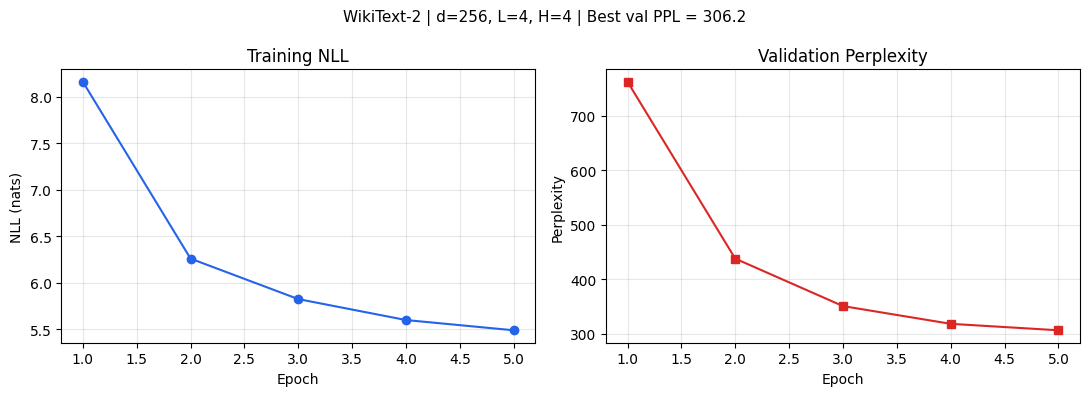

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epochs = range(1, N_EPOCHS + 1)

axes[0].plot(epochs, history["train_nll"], marker="o", color="#2563eb")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("NLL (nats)")
axes[0].set_title("Training NLL")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["valid_ppl"], marker="s", color="#dc2626")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Validation Perplexity")
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f"WikiText-2 | d={D_MODEL}, L={N_LAYERS}, H={N_HEADS} | "
    f"Best val PPL = {min(history['valid_ppl']):.1f}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 4. Baseline Autoregressive Generation Without KV Cache

First, I implement the naive decoding strategy. Given a prompt of length $P$, the model generates one token at a time. At each step, the **entire current sequence** is fed back through the Transformer.

This means that when generating token $t+1$, the model re-computes all keys and values for positions $1,\dots,t$, even though these values are unchanged. This is the redundancy that the KV cache will remove in Exercise 1.

To keep the JAX computation shape-static, a fixed-size padded buffer is pre-allocated. This avoids recompilation during the generation loop.

In [ ]:
import time

@eqx.filter_jit
def _fwd_no_cache(model, token_ids, key):
    """Full forward pass on a fixed-length sequence."""
    return model(token_ids, key=key, deterministic=True)


def generate_text_no_cache(model, prompt_ids, max_new_tokens, key):
    """
    Greedy decoding without a KV cache.

    The full sequence is re-processed at each step.
    """
    total_len = min(len(prompt_ids) + max_new_tokens, CONTEXT_LEN)
    max_new_tokens = total_len - len(prompt_ids)

    buf = jnp.zeros(total_len, dtype=jnp.int32)
    buf = buf.at[:len(prompt_ids)].set(jnp.array(prompt_ids, dtype=jnp.int32))

    current_len = len(prompt_ids)

    for _ in range(max_new_tokens):
        key, subkey = jr.split(key)

        logits = _fwd_no_cache(model, buf, subkey)
        next_token = int(jnp.argmax(logits[current_len - 1]))

        buf = buf.at[current_len].set(next_token)
        current_len += 1

    return buf[:current_len].tolist()

### Qualitative Demo

This cell simply verifies that the trained baseline model can generate text autoregressively. At this stage, the decoding is still computationally inefficient because there is no cache.

In [ ]:

# model was initialised with key: SEED

"""
model_key = jr.PRNGKey(SEED)
model = TransformerLM(
    vocab_size=VOCAB_SIZE,
    context_len=CONTEXT_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    key=model_key,
)

"""

prompt_text = "The history of the Roman Empire"
prompt_ids = tokenizer.encode(prompt_text)

gen_key = jr.PRNGKey(SEED + 999)
final_ids = generate_text_no_cache(model, prompt_ids, max_new_tokens=30, key=gen_key)

final_text = tokenizer.decode(final_ids)
print("\n--- Baseline Output (No Cache) ---")
print(final_text)

---
## Exercise 1 — Key-Value Cache for Efficient Autoregressive Decoding

### Motivation

In a decoder-only Transformer, autoregressive generation proceeds one token at a time. At decoding step $t$, the model predicts the next token using the prefix $x_{1:t}$. In the **naive** implementation, this means the full sequence is passed through the Transformer again at every step.

This is inefficient because the key and value projections for the already-processed prefix do not change. Once token $x_j$ has been embedded and passed through a self-attention layer, its key and value vectors at that layer are fixed. Therefore, recomputing them at every later decoding step is redundant.

### KV Cache Idea

The **KV cache** stores, for every decoder layer and every past token position:
- the key tensor $K$,
- the value tensor $V$.

At the next decoding step, only the current token's query, key, and value need to be computed. The new key and value are appended to the cache, while the previous ones are reused. This avoids repeated work and substantially accelerates autoregressive decoding.

### Prefill and Decode

Inference naturally splits into two phases:

1. **Prefill**: process the full prompt once and populate the KV cache for all prompt positions.
2. **Decode**: generate new tokens one by one, reading old keys/values from cache and writing only the new token's key/value pair.

This prefill/decode distinction is central in modern Transformer inference systems. Prefill is compute-heavy and parallel; decoding is more latency-sensitive and increasingly memory-bandwidth bound because the model repeatedly reads the growing KV cache.

### Complexity

Without caching, every decoding step recomputes attention over the full prefix, causing repeated projection work over all previous tokens. With caching, previous $K$ and $V$ tensors are reused, so each step only computes projections for the newly generated token. This reduces redundant computation and improves throughput substantially in practice.

### Cache Memory Cost

For $L$ layers, $H$ heads, head dimension $d_h$, maximum sequence length $T$, and one floating-point format, the KV cache memory grows as:
$$
\text{KV cache size} \propto 2 \cdot L \cdot H \cdot T \cdot d_h
$$
where the factor 2 accounts for storing both keys and values. This memory-compute trade-off is one of the defining characteristics of Transformer inference.

### Ex1 Part A — KV-Cache Multi-Head Self-Attention

The goal is to extend the baseline attention layer so that it supports **two modes**:

1. **Training mode** (`cache=None`): identical to the baseline, processing the full sequence in parallel.
2. **Inference mode** (`cache` provided): process only a single token and update the cache.

This yields a dual-purpose attention module:
- during training, it behaves exactly like standard masked self-attention;
- during inference, it consumes one token at a time and reuses all previously cached keys and values.

### JAX-specific design

In PyTorch, one can often append new keys and values dynamically via concatenation. In JAX, however, changing tensor shapes inside a JIT-compiled function triggers recompilation. Therefore, the cache is implemented as a **pre-allocated static buffer** with shape:
$$
(H,\; T_{\max},\; d_h)
$$
for both keys and values.

The new key/value slice is written into the buffer at index `step` using:
`jax.lax.dynamic_update_slice(...)`.


In [ ]:
import jax.lax as lax

class KVCacheMultiHeadSelfAttention(eqx.Module):
    W_q:          eqx.nn.Linear
    W_k:          eqx.nn.Linear
    W_v:          eqx.nn.Linear
    W_o:          eqx.nn.Linear
    attn_dropout: eqx.nn.Dropout
    n_heads:      int = eqx.field(static=True)
    d_head:       int = eqx.field(static=True)

    def __init__(self, d_model, n_heads, dropout, *, key):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.W_q = eqx.nn.Linear(d_model, d_model, use_bias=False, key=k1)
        self.W_k = eqx.nn.Linear(d_model, d_model, use_bias=False, key=k2)
        self.W_v = eqx.nn.Linear(d_model, d_model, use_bias=False, key=k3)
        self.W_o = eqx.nn.Linear(d_model, d_model, use_bias=True,  key=k4)
        self.attn_dropout = eqx.nn.Dropout(p=dropout)
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

    def __call__(self, x, *, key, deterministic=False, cache=None, step=None):
        H, Dh = self.n_heads, self.d_head
        scale = math.sqrt(Dh)

        #  Training path: full sequence
        if cache is None:
            T = x.shape[0]
            q = jax.vmap(self.W_q)(x)
            k = jax.vmap(self.W_k)(x)
            v = jax.vmap(self.W_v)(x)

            def split_heads(z):
                return z.reshape(T, H, Dh).transpose(1, 0, 2)

            q, k, v = split_heads(q), split_heads(k), split_heads(v)
            scores = jnp.einsum("hid,hjd->hij", q, k) / scale

            mask = causal_mask(T)
            scores = jnp.where(mask[None, :, :], scores, -1e9)

            weights = jax.nn.softmax(scores, axis=-1)
            weights = self.attn_dropout(weights, key=key, inference=deterministic)

            out = jnp.einsum("hij,hjd->hid", weights, v)
            out = out.transpose(1, 0, 2).reshape(T, H * Dh)
            return jax.vmap(self.W_o)(out), None

        # Inference path: single token + KV cache
        else:
            k_cache, v_cache = cache
            max_t = k_cache.shape[1]

            q = self.W_q(x).reshape(H, Dh)
            k = self.W_k(x).reshape(H, Dh)
            v = self.W_v(x).reshape(H, Dh)

            k_cache = lax.dynamic_update_slice(k_cache, k[:, None, :], (0, step, 0))
            v_cache = lax.dynamic_update_slice(v_cache, v[:, None, :], (0, step, 0))

            scores = jnp.einsum("hd,htd->ht", q, k_cache) / scale

            valid_mask = jnp.arange(max_t) <= step
            scores = jnp.where(valid_mask[None, :], scores, -1e9)

            weights = jax.nn.softmax(scores, axis=-1)

            out = jnp.einsum("ht,htd->hd", weights, v_cache)
            out = out.reshape(H * Dh)

            new_cache = (k_cache, v_cache)
            return self.W_o(out), new_cache

### Ex1 Part B — KV-Cache Transformer Block and Full Language Model

The KV-cache model must remain **architecturally identical** to the baseline model. This is crucial for two reasons:

1. The training-mode forward pass must produce the same outputs as the baseline.
2. Any speed-up should come purely from the inference implementation, not from changing the model itself.

Therefore:
- the same token embeddings, positional embeddings, and output weight tying are used;
- the same number of layers, heads, and hidden dimensions are kept;
- only the attention pathway is extended with cache support.

In [ ]:
class KVCacheTransformerBlock(eqx.Module):
    ln_1: eqx.nn.LayerNorm
    attn: KVCacheMultiHeadSelfAttention
    ln_2: eqx.nn.LayerNorm
    ff:   FeedForward

    def __init__(self, d_model, n_heads, d_ff, dropout, *, key):
        k_attn, k_ff = jr.split(key)
        self.ln_1 = eqx.nn.LayerNorm(d_model)
        self.attn = KVCacheMultiHeadSelfAttention(d_model, n_heads, dropout, key=k_attn)
        self.ln_2 = eqx.nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, d_ff, dropout, key=k_ff)

    def __call__(self, x, *, key, deterministic=False, cache=None, step=None):
        k_attn, k_ff = jr.split(key)

        if cache is None:
            attn_out, _ = self.attn(
                jax.vmap(self.ln_1)(x),
                key=k_attn,
                deterministic=deterministic,
            )
            x = x + attn_out

            ff_out = jax.vmap(
                lambda tok, k: self.ff(tok, key=k, deterministic=deterministic)
            )(jax.vmap(self.ln_2)(x), jr.split(k_ff, x.shape[0]))

            return x + ff_out, None

        else:
            attn_out, new_cache = self.attn(
                self.ln_1(x),
                key=k_attn,
                deterministic=True,
                cache=cache,
                step=step,
            )
            x = x + attn_out
            ff_out = self.ff(self.ln_2(x), key=k_ff, deterministic=True)
            return x + ff_out, new_cache

In [ ]:
class KVCacheTransformerLM(eqx.Module):
    token_emb:   eqx.nn.Embedding
    pos_emb:     jnp.ndarray
    blocks:      list
    ln_f:        eqx.nn.LayerNorm
    emb_dropout: eqx.nn.Dropout
    n_heads:     int = eqx.field(static=True)
    d_head:      int = eqx.field(static=True)

    def __init__(self, vocab_size, context_len, d_model, n_heads, n_layers, d_ff, dropout, *, key):
        keys = jr.split(key, n_layers + 3)

        raw_emb = eqx.nn.Embedding(vocab_size, d_model, key=keys[0])
        scaled_weights = jr.normal(keys[1], (vocab_size, d_model)) * 0.02
        self.token_emb = eqx.tree_at(lambda e: e.weight, raw_emb, scaled_weights)

        self.pos_emb = jr.normal(keys[2], (context_len, d_model)) * 0.02

        self.blocks = [
            KVCacheTransformerBlock(d_model, n_heads, d_ff, dropout, key=keys[i + 3])
            for i in range(n_layers)
        ]
        self.ln_f = eqx.nn.LayerNorm(d_model)
        self.emb_dropout = eqx.nn.Dropout(p=dropout)
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

    def init_cache(self, max_seq_len):
        """
        Allocate one (K_cache, V_cache) pair per layer.
        Shape per cache tensor: (n_heads, max_seq_len, d_head)
        """
        return [
            (
                jnp.zeros((self.n_heads, max_seq_len, self.d_head)),
                jnp.zeros((self.n_heads, max_seq_len, self.d_head)),
            )
            for _ in self.blocks
        ]

    def __call__(self, token_ids, *, key, deterministic=False, cache=None, step=None):
        keys = jr.split(key, len(self.blocks) + 1)

        if cache is None:
            # Training mode
            T = token_ids.shape[0]
            x = jax.vmap(self.token_emb)(token_ids)
            x = x + self.pos_emb[:T]
            x = self.emb_dropout(x, key=keys[0], inference=deterministic)

            for block, k in zip(self.blocks, keys[1:]):
                x, _ = block(x, key=k, deterministic=deterministic)

            x = jax.vmap(self.ln_f)(x)
            return x @ self.token_emb.weight.T, None

        else:
            # Inference mode: single token
            x = self.token_emb(token_ids)
            x = x + self.pos_emb[step]
            x = self.emb_dropout(x, key=keys[0], inference=True)

            new_caches = []
            for block, c, k in zip(self.blocks, cache, keys[1:]):
                x, new_c = block(x, key=k, deterministic=True, cache=c, step=step)
                new_caches.append(new_c)

            x = self.ln_f(x)
            logits = x @ self.token_emb.weight.T
            return logits, new_caches

In [ ]:
kv_model_check = KVCacheTransformerLM(
    vocab_size=VOCAB_SIZE, context_len=CONTEXT_LEN,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
    d_ff=D_FF, dropout=DROPOUT,
    key=jr.PRNGKey(SEED),
)
n_kv_params = sum(
    x.size for x in jax.tree_util.tree_leaves(eqx.filter(kv_model_check, eqx.is_array))
)
print(f"Baseline params : {n_params:,}")
print(f"KV model params : {n_kv_params:,}")
assert n_kv_params == n_params
print("Parameter counts match.")

### Ex1 Part C — Training the KV-Cache Model

The KV cache is an **inference optimisation**, not a different learning algorithm. During training, the KV model is called with `cache=None`, so it behaves exactly like a standard full-sequence Transformer.

In [ ]:
def kv_cross_entropy_loss(model, token_ids, targets, *, key):
    B = token_ids.shape[0]
    seq_keys = jr.split(key, B)

    logits, _ = jax.vmap(
        lambda ids, k: model(ids, key=k, deterministic=False, cache=None)
    )(token_ids, seq_keys)

    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
    ).mean()
    return loss

In [ ]:
@eqx.filter_jit
def kv_train_step(model, opt_state, token_ids, targets, *, key):
    loss, grads = eqx.filter_value_and_grad(kv_cross_entropy_loss)(
        model, token_ids, targets, key=key
    )

    updates, new_opt_state = optimizer.update(
        grads,
        opt_state,
        eqx.filter(model, eqx.is_array),
    )

    new_model = eqx.apply_updates(model, updates)
    return loss, new_model, new_opt_state

In [ ]:
@eqx.filter_jit
def kv_eval_batch_loss(model, token_ids, targets, *, key):
    B = token_ids.shape[0]

    logits, _ = jax.vmap(
        lambda ids, k: model(ids, key=k, deterministic=True, cache=None)
    )(token_ids, jr.split(key, B))

    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
    ).mean()
    return loss


def kv_evaluate(model, chunks, *, key):
    total_nll = 0.0
    n_batches = 0

    for x_np, y_np in make_batches(chunks, BATCH_SIZE, shuffle=False):
        key, subkey = jr.split(key)
        batch_nll = float(kv_eval_batch_loss(
            model,
            jnp.array(x_np),
            jnp.array(y_np),
            key=subkey,
        ))
        total_nll += batch_nll
        n_batches += 1

    mean_nll = total_nll / n_batches
    return math.exp(mean_nll)

In [ ]:

kv_model = KVCacheTransformerLM(
    vocab_size=VOCAB_SIZE,
    context_len=CONTEXT_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    key=jr.PRNGKey(SEED),
)

kv_opt_state = optimizer.init(eqx.filter(kv_model, eqx.is_array))
kv_step_key = jr.PRNGKey(SEED + 201)
kv_history = {"train_nll": [], "valid_ppl": []}

In [ ]:
print("Training KV-cache model...")

for epoch in range(1, N_EPOCHS + 1):
    epoch_nlls = []

    pbar = tqdm(
        make_batches(train_chunks, BATCH_SIZE, shuffle=True, rng=np.random.default_rng(SEED + epoch)),
        total=n_train_batches,
        desc=f"KV Epoch {epoch}/{N_EPOCHS}",
        leave=False,
    )

    for x_np, y_np in pbar:
        kv_step_key, subkey = jr.split(kv_step_key)

        loss, kv_model, kv_opt_state = kv_train_step(
            kv_model,
            kv_opt_state,
            jnp.array(x_np),
            jnp.array(y_np),
            key=subkey,
        )

        nll_val = float(loss)
        epoch_nlls.append(nll_val)
        pbar.set_postfix({"nll": f"{nll_val:.3f}"})

    mean_train_nll = float(np.mean(epoch_nlls))
    kv_history["train_nll"].append(mean_train_nll)

    kv_step_key, eval_key = jr.split(kv_step_key)
    val_ppl = kv_evaluate(kv_model, valid_chunks, key=eval_key)
    kv_history["valid_ppl"].append(val_ppl)

    print(
        f"Epoch {epoch:2d}/{N_EPOCHS}  |  "
        f"train NLL {mean_train_nll:.4f}  |  "
        f"valid PPL {val_ppl:.1f}"
    )

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epochs = range(1, N_EPOCHS + 1)

axes[0].plot(epochs, kv_history["train_nll"], marker="o", color="purple")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("NLL (nats)")
axes[0].set_title("KV Model Training NLL")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, kv_history["valid_ppl"], marker="s", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("KV Model Validation Perplexity")
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f"KV-Cache Transformer | d={D_MODEL}, L={N_LAYERS}, H={N_HEADS} | "
    f"Best val PPL = {min(kv_history['valid_ppl']):.1f}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### Ex1 Part D — Cached Autoregressive Generation

The generation loop is divided into two phases.

### Prefill phase

The prompt tokens are processed one-by-one. For each prompt token:
- its embedding is computed,
- each layer writes that token's \(K\) and \(V\) into the corresponding cache buffer.

After prefill, the cache contains the full prompt history.

### Decode phase

From that point onward, each step uses only:
- the most recent token as input,
- the cached keys and values for all previous tokens.

This is exactly the optimisation described in the KV-cache literature: the model computes the new query/key/value only once and reuses all historical attention state.

In [ ]:
@eqx.filter_jit
def generate_step_with_cache(model, single_token_id, cache, step, key):
    """
    Single-token forward pass with cache update.
    """
    logits, new_cache = model(
        jnp.array(single_token_id, dtype=jnp.int32),
        key=key,
        deterministic=True,
        cache=cache,
        step=step,
    )
    return logits, new_cache

In [ ]:
def generate_text_with_cache(model, prompt_ids, max_new_tokens, key):
    """
    Greedy decoding with KV cache.
    1. Prefill : feed each prompt token through the cache path.
    2. Decode  : generate new tokens one-by-one using cached K/V tensors.
    """
    prompt_len = len(prompt_ids)
    total_len  = min(prompt_len + max_new_tokens, CONTEXT_LEN)
    max_new_tokens = total_len - prompt_len

    cache = model.init_cache(max_seq_len=total_len)
    generated_ids = list(prompt_ids)

    # Prefill
    for step in range(prompt_len):
        key, subkey = jr.split(key)
        _, cache = generate_step_with_cache(
            model, generated_ids[step], cache, jnp.int32(step), subkey
        )

    # Decode
    for step in range(prompt_len, total_len):
        key, subkey = jr.split(key)
        logits, cache = generate_step_with_cache(
            model, generated_ids[-1], cache, jnp.int32(step - 1), subkey
        )
        next_token = int(jnp.argmax(logits, axis=-1))
        generated_ids.append(next_token)

    return generated_ids

In [ ]:

# model was initialised with key: SEED

"""
kv_model = KVCacheTransformerLM(
    vocab_size=VOCAB_SIZE,
    context_len=CONTEXT_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    key=jr.PRNGKey(SEED),
)

"""

prompt_text = "The history of the Roman Empire"
prompt_ids = tokenizer.encode(prompt_text)

gen_key = jr.PRNGKey(SEED + 999)
final_ids = generate_text_with_cache(kv_model, prompt_ids, max_new_tokens=30, key=gen_key)

final_text = tokenizer.decode(final_ids)
print("\n--- KV-Cache Output ---")
print(final_text)

### Ex1 Part E — Speed Benchmark and Final Correctness Check

A benchmark must compare:
- the **same decoding task**,
- with the **same prompt**,

The  no-cache implementation repeatedly reprocesses the full sequence. The cached implementation processes one token at a time while reading the stored KV states. Therefore, both implementations should generate the **same output tokens**, but the cached version should be faster.


In [ ]:
def generate_no_cache_with_kv_model(model, prompt_ids, max_new_tokens, key):
    """
    No-cache decoding using KVCacheTransformerLM in training pathway (cache=None).
    This gives a fair comparison with the cached pathway on the same model.
    """
    total_len = min(len(prompt_ids) + max_new_tokens, CONTEXT_LEN)
    max_new_tokens = total_len - len(prompt_ids)

    buf = jnp.zeros(total_len, dtype=jnp.int32)
    buf = buf.at[:len(prompt_ids)].set(jnp.array(prompt_ids, dtype=jnp.int32))
    current_len = len(prompt_ids)

    for _ in range(max_new_tokens):
        key, subkey = jr.split(key)
        logits, _ = model(buf, key=subkey, deterministic=True, cache=None)
        next_token = int(jnp.argmax(logits[current_len - 1]))
        buf = buf.at[current_len].set(next_token)
        current_len += 1

    return buf[:current_len].tolist()

In [ ]:
MAX_NEW_TOKENS = 100
dummy_prompt   = tokenizer.encode("The")
print("Running warm-up calls to trigger JIT compilation...")
_ = generate_no_cache_with_kv_model(kv_model, dummy_prompt, 2, key=jr.PRNGKey(0))
_ = generate_text_with_cache(kv_model, dummy_prompt, 2, key=jr.PRNGKey(0))
print("Warm-up complete.\n")

t0              = time.time()
baseline_output = generate_no_cache_with_kv_model(kv_model, dummy_prompt, MAX_NEW_TOKENS, key=jr.PRNGKey(42))
jax.block_until_ready(jnp.array(baseline_output))
baseline_time   = time.time() - t0
print(f"No-cache  : {baseline_time:.2f}s  |  {MAX_NEW_TOKENS/baseline_time:.1f} tok/s")

t0        = time.time()
kv_output = generate_text_with_cache(kv_model, dummy_prompt, MAX_NEW_TOKENS, key=jr.PRNGKey(42))
jax.block_until_ready(jnp.array(kv_output))
kv_time   = time.time() - t0
print(f"KV-cache  : {kv_time:.2f}s  |  {MAX_NEW_TOKENS/kv_time:.1f} tok/s")
print(f"Speedup   : {baseline_time/kv_time:.2f}x")

Due to small dataset size and deliberate model configurations due to GPU limitations, there is not a massive increase in the speed up but the speed up is still evident.

## Description of the Code: KV Cache Compression with KnormPress

For this exercise, I am reimplementing a **basic version** of **KnormPress**, a KV-cache compression strategy from NVIDIA's `kvpress` library, adapted for our JAX/Equinox Transformer. The core idea is based on the observation that we don't actually need to remember every single past word to generate coherent text. Research (Devoto et al., 2024) shows that tokens whose Key vectors have a **low L2 norm** tend to receive the highest attention scores later on.

Therefore, instead of keeping the entire history, this algorithm simply ranks the cached key/value pairs by their Key L2 norm and throws away the ones with the highest norms (the "least important" ones). This is incredibly efficient because it is "query-free" - no need to calculate future attention weights or retrain the model to do this; just apply it immediately after the prefill phase.

### Implementation Strategy & Layer Skipping

Because our JAX implementation relies heavily on static, pre-allocated array shapes (our cache is a fixed `(H, T, d_h)` size), physically shrinking the tensor would cause the XLA compiler to panic and recompile.

Instead, my implementation does a **packing operation**:
1. Calculate the norms and select the top `K` most important tokens.
2. Pack those surviving tokens into the very front of our fixed-size cache (indices `0` to `K-1`).
3. Zero out the rest of the array.

Additionally, I've added a `skip_layers` parameter (defaulting to the first two layers). The literature notes that the L2 norm heuristic isn't as strongly correlated with importance in the very early layers of a Transformer, so it is safer to leave those initial caches uncompressed.

In [ ]:
# Helper Functions

def prefill_cache(model, prompt_ids, key):
    """
    Run the prompt through the KV-cache model token-by-token and return:
      - the populated cache
      - the logits of the final prompt token
      - the prompt length

    This mirrors the prefill phase from Exercise 1, but stops before decoding.
    """
    prompt_len = len(prompt_ids)
    cache = model.init_cache(max_seq_len=prompt_len)

    last_logits = None
    for step in range(prompt_len):
        token_id = prompt_ids[step]
        key, subkey = jr.split(key)
        last_logits, cache = generate_step_with_cache(
            model, token_id, cache, step, subkey
        )

    return cache, last_logits, prompt_len

In [ ]:
def key_l2_norms(k_cache: jnp.ndarray, valid_len: int) -> jnp.ndarray:
    """
    Compute L2 norms of cached keys.

    Parameters
    ----------
    k_cache   : jnp.ndarray, shape (H, T, Dh)
    valid_len : int, number of valid cached positions

    Returns
    -------
    norms : jnp.ndarray, shape (H, valid_len)
        L2 norm of each key vector for each head.
    """
    valid_k = k_cache[:, :valid_len, :]                    # (H, valid_len, Dh)
    norms = jnp.linalg.norm(valid_k, axis=-1)              # (H, valid_len)
    return norms

In [ ]:
def pack_along_time(x: jnp.ndarray, kept_idx: jnp.ndarray) -> jnp.ndarray:
    """
    Gather selected time positions independently per head and pack them into
    the front of a fixed-size tensor.

    Parameters
    ----------
    x        : jnp.ndarray, shape (H, T, Dh)
    kept_idx : jnp.ndarray, shape (H, K)
              indices to keep for each head, sorted in ascending time order

    Returns
    -------
    packed : jnp.ndarray, shape (H, T, Dh)
        First K positions contain the kept entries; remaining positions are zero.
    """
    H, T, Dh = x.shape
    K = kept_idx.shape[1]

    def gather_one_head(h):
        gathered = x[h, kept_idx[h], :]                    # (K, Dh)
        out = jnp.zeros((T, Dh), dtype=x.dtype)
        out = out.at[:K].set(gathered)
        return out

    return jax.vmap(gather_one_head)(jnp.arange(H))        # (H, T, Dh)

In [ ]:
def knorm_press_layer(
    layer_cache,
    valid_len: int,
    compression_ratio: float,
):
    """
    Apply KnormPress to one layer's KV cache.

    Parameters
    ----------
    layer_cache        : tuple (k_cache, v_cache)
                         each of shape (H, T, Dh)
    valid_len          : int
                         number of valid cache positions currently populated
    compression_ratio  : float in [0, 1)
                         fraction of positions to remove

    Returns
    -------
    new_layer_cache : tuple (new_k, new_v), same shapes as input
    keep_idx        : jnp.ndarray, shape (H, K)
    keep_mask       : jnp.ndarray, shape (H, valid_len)
    new_valid_len   : int
    norm_scores     : jnp.ndarray, shape (H, valid_len)
    """
    k_cache, v_cache = layer_cache
    H, T, Dh = k_cache.shape

    assert 0.0 <= compression_ratio < 1.0, "compression_ratio must be in [0, 1)."

    n_keep = max(1, int(round(valid_len * (1.0 - compression_ratio))))

    # Compute norms over the valid prefix only.
    norms = key_l2_norms(k_cache, valid_len)               # (H, valid_len)

    # Lower norm = more important. We therefore keep the smallest norms.
    # argsort ascending already gives lowest norms first.
    sorted_idx = jnp.argsort(norms, axis=-1)               # (H, valid_len)
    keep_idx = sorted_idx[:, :n_keep]                      # (H, n_keep)

    # Sort again by time so the packed cache preserves chronological order.
    keep_idx = jnp.sort(keep_idx, axis=-1)                 # (H, n_keep)

    # Boolean keep mask for statistics.
    keep_mask = jnp.zeros((H, valid_len), dtype=bool)

    def fill_mask_for_head(mask_row, idx_row):
        return mask_row.at[idx_row].set(True)

    keep_mask = jax.vmap(fill_mask_for_head)(keep_mask, keep_idx)

    # Pack selected KV pairs into the front of fixed-size tensors.
    new_k = pack_along_time(k_cache, keep_idx)
    new_v = pack_along_time(v_cache, keep_idx)

    return (new_k, new_v), keep_idx, keep_mask, n_keep, norms

In [ ]:
def knorm_press_cache(
    cache,
    valid_len: int,
    compression_ratio: float = 0.5,
    skip_layers: tuple = (0, 1),
):
    """
    Apply KnormPress independently to each layer of the Transformer cache.

    Parameters
    ----------
    cache              : list of layer caches, one per layer
    valid_len          : int
    compression_ratio  : float
    skip_layers        : tuple of layer indices not to compress

    Returns
    -------
    compressed_cache : list of layer caches
    compressed_len   : int
    stats            : list of dicts with per-layer diagnostics
    """
    compressed_cache = []
    stats = []
    compressed_len = None

    for layer_id, layer_cache in enumerate(cache):
        if layer_id in skip_layers:
            compressed_cache.append(layer_cache)
            H, T, Dh = layer_cache[0].shape
            stats.append({
                "layer": layer_id,
                "skipped": True,
                "before_len": valid_len,
                "after_len": valid_len,
                "compression_ratio": 0.0,
                "keep_idx": None,
                "keep_mask": jnp.ones((H, valid_len), dtype=bool),
                "norms": key_l2_norms(layer_cache[0], valid_len),
            })
        else:
            new_layer_cache, keep_idx, keep_mask, new_valid_len, norms = knorm_press_layer(
                layer_cache,
                valid_len=valid_len,
                compression_ratio=compression_ratio,
            )
            compressed_cache.append(new_layer_cache)

            if compressed_len is None:
                compressed_len = new_valid_len

            stats.append({
                "layer": layer_id,
                "skipped": False,
                "before_len": valid_len,
                "after_len": new_valid_len,
                "compression_ratio": 1.0 - new_valid_len / valid_len,
                "keep_idx": keep_idx,
                "keep_mask": keep_mask,
                "norms": norms,
            })

    if compressed_len is None:
        compressed_len = valid_len

    return compressed_cache, compressed_len, stats

### The Compressed Generation Loop

Integrating this into our generation loop requires a specific sequence of events. Instead of compressing at every single step, I do it exactly once:
1. **Prefill:** I run the entire prompt through the model to populate the initial uncompressed cache.
2. **Compress:** I pass that cache through our `knorm_press_cache` function, which packs the most important tokens to the front and returns a new, smaller `compressed_len`.
3. **Decode:** I resume our standard autoregressive decoding, but I tell the model to start reading and writing from the new `compressed_len` index instead of the original prompt length.

In [ ]:
def generate_text_with_compressed_cache(
    model,
    prompt_ids,
    max_new_tokens,
    compression_ratio,
    skip_layers=(0, 1),
    key=jr.PRNGKey(0),
):
    """
    Prefill -> compress cache with KnormPress -> continue greedy decoding.

    Returns
    -------
    generated_ids : list[int]
    compressed_stats : list[dict]
    """
    prompt_len = len(prompt_ids)
    total_len = min(prompt_len + max_new_tokens, CONTEXT_LEN)
    max_new_tokens = total_len - prompt_len

    # 1. Prefill
    key, prefill_key = jr.split(key)
    cache, last_logits, valid_len = prefill_cache(model, prompt_ids, prefill_key)

    # 2. Compress once after prefill
    compressed_cache, compressed_len, stats = knorm_press_cache(
        cache,
        valid_len=valid_len,
        compression_ratio=compression_ratio,
        skip_layers=skip_layers,
    )

    # 3. Decode from the compressed cache
    generated_ids = list(prompt_ids)

    # First predicted token comes from the last prompt logits
    next_token = int(jnp.argmax(last_logits, axis=-1))
    generated_ids.append(next_token)

    # Continue decoding; note that the cache now effectively starts at compressed_len
    current_step = compressed_len

    for _ in range(max_new_tokens - 1):
        current_token = generated_ids[-1]
        key, subkey = jr.split(key)

        logits, compressed_cache = generate_step_with_cache(
            model,
            current_token,
            compressed_cache,
            current_step,
            subkey,
        )

        next_token = int(jnp.argmax(logits, axis=-1))
        generated_ids.append(next_token)
        current_step += 1

        if current_step >= total_len:
            break

    return generated_ids, stats

In [ ]:
prompt_text = "The history of the Roman Empire"
prompt_ids = tokenizer.encode(prompt_text)

generate_text_with_cache(kv_model, prompt_ids, max_new_tokens=30, key=gen_key)

final_text = tokenizer.decode(final_ids)
print("\n--- KV-Cache Output ---")
print(final_text)

kn_key = jr.PRNGKey(SEED + 5000)
kn_ids, kn_stats = generate_text_with_compressed_cache(
    kv_model,
    prompt_ids,
    max_new_tokens=30,
    compression_ratio=0.5,
    skip_layers=(0, 1),
    key=kn_key,
)

print("\n--- KnormPress Output (50% compression, skip layers 0 and 1) ---")
print(tokenizer.decode(kn_ids))

For a basic implementation, the text generated by the compressed cache still makes contextual sense, proving that the L2 norm is a valid heuristic for identifying which tokens I can safely forget.

In [ ]:
print(f"{'Layer':>5} | {'Skipped':>7} | {'Before':>6} | {'After':>5} | {'Compression':>11}")
print("-" * 48)

for s in kn_stats:
    print(
        f"{s['layer']:>5} | "
        f"{str(s['skipped']):>7} | "
        f"{s['before_len']:>6} | "
        f"{s['after_len']:>5} | "
        f"{100 * s['compression_ratio']:>10.1f}%"
    )

In [ ]:
layers = [s["layer"] for s in kn_stats]
before = [s["before_len"] for s in kn_stats]
after = [s["after_len"] for s in kn_stats]

x = np.arange(len(layers))
w = 0.36

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, before, width=w, label="Before compression", color="#94a3b8")
ax.bar(x + w/2, after,  width=w, label="After compression",  color="#2563eb")
ax.set_xticks(x)
ax.set_xticklabels([str(l) for l in layers])
ax.set_xlabel("Layer")
ax.set_ylabel("Number of valid cached positions")
ax.set_title("KV cache size before/after KnormPress")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion & Results

The experiments demonstrate that KnormPress can be cleanly integrated into a JAX-based KV-cache pipeline.

Looking at the cache-size statistics and plots, I can see the method successfully reduces the active KV cache memory footprint of the sequence by our target compression ratio (e.g., 50%), effectively halving the number of dot-products the attention mechanism has to compute during generation, while minimum difference on the decoded text.